# Solar Inspection — RGB + Thermal Video Testing

Complete V1 video-testing notebook for two independent videos.

**RGB:** panel segmentation → RGB defect detection → RGB defect-to-panel association.

**Thermal:** hotspot detection, executed only when at least one RGB panel is detected. RGB and thermal coordinates are never mixed.


In [1]:
from pathlib import Path
from datetime import datetime
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

/home/hraj/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
PROJECT_ROOT = Path("/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection")
OUTPUT_DIR = PROJECT_ROOT / "output" / "video_testing"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RGB_VIDEO = Path("/home/hraj/Pictures/rgb_solar.mp4")
THERMAL_VIDEO = Path("/home/hraj/Pictures/thermal_solar.mp4")

PANEL_MODEL = Path("/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/pannel_segment/runs/weights/best.onnx")
RGB_DEFECT_MODEL = Path("/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/rgb_defect_detection/baseline/runs/detect/baseline/weights/best.onnx")
THERMAL_MODEL = Path("/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx")

IMG_SIZE = 640
PANEL_CONFIDENCE = 0.10
RGB_DEFECT_CONFIDENCE = 0.10
THERMAL_CONFIDENCE = 0.10
FRAME_STRIDE = 1
INSPECTION_ID = "VIDEO-INS-001"

print("Configuration loaded.")


Configuration loaded.


In [3]:
# Validate videos and models
for p, label in [(RGB_VIDEO, "RGB video"), (THERMAL_VIDEO, "Thermal video"),
                  (PANEL_MODEL, "Panel model"), (RGB_DEFECT_MODEL, "RGB defect model"),
                  (THERMAL_MODEL, "Thermal model")]:
    if not p.is_file():
        raise FileNotFoundError(f"{label} not found:\n{p}")
    print(f"✓ {label}: {p}")


✓ RGB video: /home/hraj/Pictures/rgb_solar.mp4
✓ Thermal video: /home/hraj/Pictures/thermal_solar.mp4
✓ Panel model: /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/pannel_segment/runs/weights/best.onnx
✓ RGB defect model: /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/rgb_defect_detection/baseline/runs/detect/baseline/weights/best.onnx
✓ Thermal model: /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx


In [4]:
# Load ONNX models
panel_model = YOLO(str(PANEL_MODEL))
rgb_defect_model = YOLO(str(RGB_DEFECT_MODEL))
thermal_model = YOLO(str(THERMAL_MODEL))

print("✓ All models loaded")
print("RGB classes:", rgb_defect_model.names)
print("Thermal classes:", thermal_model.names)


✓ All models loaded
Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/rgb_defect_detection/baseline/runs/detect/baseline/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
RGB classes: {0: 'bird-drop', 1: 'clean', 2: 'dusty', 3: 'electrical-damage', 4: 'physical-damage', 5: 'snow-capped'}
Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Thermal classes: {0: 'hotspot'}


## Video properties and timestamp synchronization

The current videos have different FPS/durations. We therefore pair frames by timestamp, not by frame number. Only the common duration is processed. This is temporal synchronization only; it is not geometric RGB↔thermal registration.


In [5]:
def get_video_info(cap):
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frames / fps if fps > 0 else 0.0
    return {"fps": fps, "frames": frames, "width": width, "height": height, "duration": duration}

rgb_cap = cv2.VideoCapture(str(RGB_VIDEO))
thermal_cap = cv2.VideoCapture(str(THERMAL_VIDEO))
if not rgb_cap.isOpened(): raise RuntimeError(f"Unable to open RGB video: {RGB_VIDEO}")
if not thermal_cap.isOpened(): raise RuntimeError(f"Unable to open thermal video: {THERMAL_VIDEO}")

rgb_info = get_video_info(rgb_cap)
thermal_info = get_video_info(thermal_cap)
common_duration = min(rgb_info["duration"], thermal_info["duration"])

print("RGB VIDEO")
print(f"Resolution : {rgb_info['width']} x {rgb_info['height']}")
print(f"FPS        : {rgb_info['fps']:.2f}")
print(f"Frames     : {rgb_info['frames']}")
print(f"Duration   : {rgb_info['duration']:.2f} sec")
print("\nTHERMAL VIDEO")
print(f"Resolution : {thermal_info['width']} x {thermal_info['height']}")
print(f"FPS        : {thermal_info['fps']:.2f}")
print(f"Frames     : {thermal_info['frames']}")
print(f"Duration   : {thermal_info['duration']:.2f} sec")
print(f"\nCommon duration: {common_duration:.2f} sec")


RGB VIDEO
Resolution : 768 x 432
FPS        : 25.00
Frames     : 384
Duration   : 15.36 sec

THERMAL VIDEO
Resolution : 768 x 432
FPS        : 30.00
Frames     : 301
Duration   : 10.03 sec

Common duration: 10.03 sec


In [6]:
def get_frame_at_timestamp(cap, timestamp, fps):
    index = int(round(timestamp * fps))
    cap.set(cv2.CAP_PROP_POS_FRAMES, index)
    ok, frame = cap.read()
    return frame if ok else None

def bbox_center(bbox):
    x1, y1, x2, y2 = bbox
    return ((x1+x2)/2.0, (y1+y2)/2.0)

def point_inside_bbox(point, bbox):
    x, y = point
    x1, y1, x2, y2 = bbox
    return x1 <= x <= x2 and y1 <= y <= y2

# First synchronized pair
rgb_cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ok, rgb_test = rgb_cap.read()
thermal_test = get_frame_at_timestamp(thermal_cap, 0.0, thermal_info["fps"])
if not ok or thermal_test is None:
    raise RuntimeError("Unable to read the first synchronized frame pair.")

print("RGB shape:", rgb_test.shape)
print("Thermal shape:", thermal_test.shape)


RGB shape: (432, 768, 3)
Thermal shape: (432, 768, 3)


In [7]:
def detect_panels(frame):
    result = panel_model.predict(source=frame, imgsz=IMG_SIZE, conf=PANEL_CONFIDENCE, verbose=False)[0]
    panels=[]
    if result.boxes is not None:
        for i, box in enumerate(result.boxes):
            panels.append({
                "panel_id": f"P{i+1:03d}",
                "bbox": box.xyxy[0].cpu().numpy().tolist(),
                "confidence": float(box.conf[0].cpu().numpy())
            })
    return panels

def detect_rgb_defects(frame):
    result = rgb_defect_model.predict(source=frame, imgsz=IMG_SIZE, conf=RGB_DEFECT_CONFIDENCE, verbose=False)[0]
    defects=[]
    if result.boxes is not None:
        for i, box in enumerate(result.boxes):
            cls_id=int(box.cls[0].cpu().numpy())
            defects.append({
                "defect_id": f"RGB_D{i+1:03d}",
                "class_name": result.names[cls_id],
                "confidence": float(box.conf[0].cpu().numpy()),
                "bbox": box.xyxy[0].cpu().numpy().tolist()
            })
    return defects

def associate_rgb_defects(panels, defects):
    for defect in defects:
        defect["panel_id"] = None
        center=bbox_center(defect["bbox"])
        for panel in panels:
            if point_inside_bbox(center, panel["bbox"]):
                defect["panel_id"] = panel["panel_id"]
                break
    return defects

def detect_thermal_hotspots(frame, panels):
    if not panels:
        return []
    result = thermal_model.predict(source=frame, imgsz=IMG_SIZE, conf=THERMAL_CONFIDENCE, verbose=False)[0]
    hotspots=[]
    if result.boxes is not None:
        for i, box in enumerate(result.boxes):
            cls_id=int(box.cls[0].cpu().numpy())
            hotspots.append({
                "hotspot_id": f"TH{i+1:03d}",
                "class_name": result.names[cls_id],
                "confidence": float(box.conf[0].cpu().numpy()),
                "bbox": box.xyxy[0].cpu().numpy().tolist()
            })
    return hotspots

def draw_rgb(frame, panels, defects):
    vis=frame.copy()
    for p in panels:
        x1,y1,x2,y2=map(int,p["bbox"])
        cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(vis,f"{p['panel_id']} ({p['confidence']:.2f})",(x1,max(y1-6,15)),cv2.FONT_HERSHEY_SIMPLEX,0.45,(0,255,0),2)
    for d in defects:
        x1,y1,x2,y2=map(int,d["bbox"])
        cv2.rectangle(vis,(x1,y1),(x2,y2),(0,0,255),2)
        label=f"{d['defect_id']} {d['class_name']} {d['confidence']:.2f}"
        cv2.putText(vis,label,(x1,min(y2+16,vis.shape[0]-5)),cv2.FONT_HERSHEY_SIMPLEX,0.40,(0,0,255),2)
    return vis

def draw_thermal(frame, hotspots):
    vis=frame.copy()
    for h in hotspots:
        x1,y1,x2,y2=map(int,h["bbox"])
        cv2.rectangle(vis,(x1,y1),(x2,y2),(0,0,255),2)
        label=f"{h['hotspot_id']} {h['class_name']} {h['confidence']:.2f}"
        cv2.putText(vis,label,(x1,max(y1-6,15)),cv2.FONT_HERSHEY_SIMPLEX,0.40,(0,0,255),2)
    return vis

print("✓ Inference and visualization functions ready.")


✓ Inference and visualization functions ready.


## Single-frame sanity test

Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/pannel_segment/runs/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/rgb_defect_detection/baseline/runs/detect/baseline/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Panels: 11
RGB defects: 1
Thermal hotspots: 0


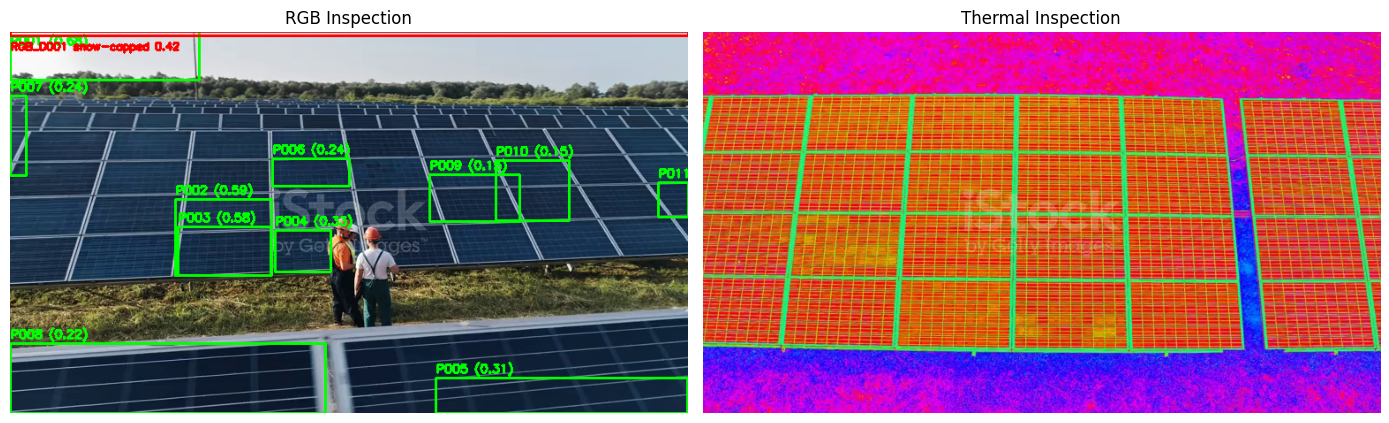

In [8]:
panels=detect_panels(rgb_test)
rgb_defects=associate_rgb_defects(panels, detect_rgb_defects(rgb_test))
thermal_hotspots=detect_thermal_hotspots(thermal_test, panels)

rgb_vis=draw_rgb(rgb_test, panels, rgb_defects)
thermal_vis=draw_thermal(thermal_test, thermal_hotspots)

print(f"Panels: {len(panels)}")
print(f"RGB defects: {len(rgb_defects)}")
print(f"Thermal hotspots: {len(thermal_hotspots)}")

plt.figure(figsize=(14,6))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(rgb_vis,cv2.COLOR_BGR2RGB)); plt.title("RGB Inspection"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(thermal_vis,cv2.COLOR_BGR2RGB)); plt.title("Thermal Inspection"); plt.axis("off")
plt.tight_layout(); plt.show()


## Complete video inference

The output is a side-by-side visualization for convenience. RGB and thermal coordinates remain independent. Thermal inference is skipped on frames where RGB panel segmentation detects no panels.


In [9]:
# Reopen videos from the beginning
rgb_cap.release(); thermal_cap.release()
rgb_cap=cv2.VideoCapture(str(RGB_VIDEO))
thermal_cap=cv2.VideoCapture(str(THERMAL_VIDEO))

output_video_path=OUTPUT_DIR/"solar_inspection_video_result.mp4"
fourcc=cv2.VideoWriter_fourcc(*"mp4v")
out_w=rgb_info["width"]+thermal_info["width"]
out_h=max(rgb_info["height"],thermal_info["height"])
out_fps=rgb_info["fps"]/FRAME_STRIDE
writer=cv2.VideoWriter(str(output_video_path),fourcc,out_fps,(out_w,out_h))
if not writer.isOpened(): raise RuntimeError(f"Unable to create {output_video_path}")

records=[]
frame_index=0
processed=0
start=datetime.now()

while True:
    ok,rgb_frame=rgb_cap.read()
    if not ok: break
    timestamp=frame_index/rgb_info["fps"]
    if timestamp>=common_duration: break
    if frame_index % FRAME_STRIDE != 0:
        frame_index+=1
        continue

    panels=detect_panels(rgb_frame)
    defects=associate_rgb_defects(panels,detect_rgb_defects(rgb_frame))
    thermal_frame=get_frame_at_timestamp(thermal_cap,timestamp,thermal_info["fps"])
    if thermal_frame is None: break
    hotspots=detect_thermal_hotspots(thermal_frame,panels)

    rgb_vis=draw_rgb(rgb_frame,panels,defects)
    thermal_vis=draw_thermal(thermal_frame,hotspots)
    if rgb_vis.shape[0]!=out_h: rgb_vis=cv2.resize(rgb_vis,(rgb_vis.shape[1],out_h))
    if thermal_vis.shape[0]!=out_h: thermal_vis=cv2.resize(thermal_vis,(thermal_vis.shape[1],out_h))
    writer.write(np.hstack([rgb_vis,thermal_vis]))

    records.append({
        "Inspection ID":INSPECTION_ID,
        "Timestamp (sec)":round(timestamp,3),
        "RGB Panels":len(panels),
        "RGB Defects":len(defects),
        "Thermal Hotspots":len(hotspots),
        "Thermal Inference":"Executed" if panels else "Skipped - No RGB Panel"
    })
    processed+=1
    frame_index+=1
    if processed % 10 == 0:
        print(f"Processed {processed} frames | t={timestamp:.2f}s | panels={len(panels)} | RGB defects={len(defects)} | thermal={len(hotspots)}")

writer.release(); rgb_cap.release(); thermal_cap.release()
elapsed=(datetime.now()-start).total_seconds()
print("\nCompleted.")
print(f"Processed frames: {processed}")
print(f"Processing time: {elapsed:.2f} sec")
print(f"Output video: {output_video_path}")


Processed 10 frames | t=0.36s | panels=13 | RGB defects=1 | thermal=0
Processed 20 frames | t=0.76s | panels=14 | RGB defects=3 | thermal=0
Processed 30 frames | t=1.16s | panels=13 | RGB defects=3 | thermal=0
Processed 40 frames | t=1.56s | panels=13 | RGB defects=3 | thermal=0
Processed 50 frames | t=1.96s | panels=13 | RGB defects=2 | thermal=0
Processed 60 frames | t=2.36s | panels=13 | RGB defects=2 | thermal=0
Processed 70 frames | t=2.76s | panels=9 | RGB defects=2 | thermal=0
Processed 80 frames | t=3.16s | panels=12 | RGB defects=2 | thermal=0
Processed 90 frames | t=3.56s | panels=9 | RGB defects=2 | thermal=0
Processed 100 frames | t=3.96s | panels=8 | RGB defects=2 | thermal=0
Processed 110 frames | t=4.36s | panels=9 | RGB defects=5 | thermal=0
Processed 120 frames | t=4.76s | panels=7 | RGB defects=2 | thermal=0
Processed 130 frames | t=5.16s | panels=10 | RGB defects=3 | thermal=0
Processed 140 frames | t=5.56s | panels=8 | RGB defects=4 | thermal=0
Processed 150 frames 

In [10]:
# Save frame-level results and final summary
frame_df=pd.DataFrame(records)
frame_csv=OUTPUT_DIR/"video_frame_results.csv"
frame_df.to_csv(frame_csv,index=False)

if len(frame_df):
    summary_df=pd.DataFrame([{
        "Inspection ID":INSPECTION_ID,
        "RGB Video":RGB_VIDEO.name,
        "Thermal Video":THERMAL_VIDEO.name,
        "RGB FPS":rgb_info["fps"],
        "Thermal FPS":thermal_info["fps"],
        "Common Duration (sec)":round(common_duration,3),
        "Processed Frames":len(frame_df),
        "Frames With RGB Panels":int((frame_df["RGB Panels"]>0).sum()),
        "Frames With RGB Defects":int((frame_df["RGB Defects"]>0).sum()),
        "Frames With Thermal Hotspots":int((frame_df["Thermal Hotspots"]>0).sum()),
        "Panel Confidence":PANEL_CONFIDENCE,
        "RGB Defect Confidence":RGB_DEFECT_CONFIDENCE,
        "Thermal Confidence":THERMAL_CONFIDENCE,
        "Generated":datetime.now().strftime("%d-%m-%Y %H:%M:%S")
    }])
else:
    summary_df=pd.DataFrame()

excel_path=OUTPUT_DIR/"solar_inspection_video_report.xlsx"
with pd.ExcelWriter(excel_path,engine="openpyxl") as writer:
    summary_df.to_excel(writer,sheet_name="Summary",index=False)
    frame_df.to_excel(writer,sheet_name="Frame Results",index=False)

print("Outputs saved:")
print("Video :",output_video_path)
print("CSV   :",frame_csv)
print("Excel :",excel_path)


Outputs saved:
Video : /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output/video_testing/solar_inspection_video_result.mp4
CSV   : /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output/video_testing/video_frame_results.csv
Excel : /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output/video_testing/solar_inspection_video_report.xlsx


## Final output structure

```text
output/video_testing/
├── solar_inspection_video_result.mp4
├── video_frame_results.csv
└── solar_inspection_video_report.xlsx
```

The Excel report contains a summary and frame-level statistics. Thermal detections are intentionally not assigned to RGB panel IDs because the current RGB and thermal videos are not geometrically registered.
